# 06 · Convergence and caching

Two questions every FDTD user hits: *how fine a mesh do I actually need?* and
*how do I avoid paying for the same run twice?* `gds_fdtd` answers both:

- **`convergence.sweep`** reruns one job while stepping a single
  `SimulationSpec` field (here `mesh`) and measures how much the S-matrix still
  moves — so you pick the coarsest grid that's already converged.
- **`run_cached`** hashes the geometry + technology + spec + engine version;
  a repeat job loads the stored S-matrix instead of recomputing it.

This runs on free **beamz**, so you can watch the cost of resolution — and the
value of the cache — without spending anything.

In [1]:
import tempfile
import time
from pathlib import Path

import gdsfactory as gf
import matplotlib.pyplot as plt

from gds_fdtd.convergence import sweep
from gds_fdtd.layout.gdsfactory import from_gdsfactory
from gds_fdtd.solvers import get_solver
from gds_fdtd.spec import SimulationSpec
from gds_fdtd.technology import Technology


def _find(rel: str) -> Path:
    for base in (Path.cwd(), *Path.cwd().parents):
        if (base / rel).exists():
            return base / rel
    raise FileNotFoundError(rel)

## 1 · A mesh convergence sweep

A short straight waveguide, run at three mesh densities. `sweep` returns a
`ConvergenceReport`; `max |ΔS|` is the worst-case change, between successive
meshes, of any S-parameter carrying real power. We set `floor_db=-10` so the
metric tracks the **transmission** and ignores the straight's deep reflection —
on a well-matched device that reflection is pure numerical noise and swings
tens of dB between meshes while being equally "zero" (see
`convergence.max_delta_db`). A `cache_dir` means the sweep only ever pays for
genuinely new points.

In [2]:
gf.gpdk.PDK.activate()
tech = Technology.from_yaml(_find("examples/tech.yaml"))
component = from_gdsfactory(gf.components.straight(length=1.5), tech)
spec = SimulationSpec(wavelength_start=1.5, wavelength_end=1.6, wavelength_points=3,
                      z_min=-0.6, z_max=0.8)

cache = Path(tempfile.mkdtemp(prefix="gdsfdtd_conv_"))
mesh_values = [4, 6, 8]
TOL_DB = 0.25  # engineering tolerance — convergence is always relative to it

t0 = time.perf_counter()
report = sweep(get_solver("beamz"), component, tech, spec,
               field="mesh", values=mesh_values, cache_dir=cache, floor_db=-10.0)
cold = time.perf_counter() - t0

for lo, hi, d in zip(mesh_values, mesh_values[1:], report.deltas_db):
    print(f"mesh {lo} → {hi}:  max |ΔS| = {d:.3f} dB")
print(f"\nsweep wall time (all new points): {cold:.1f} s")

● Done: Raster cache hit (3d): 25986b9b7a7be653deb9ea6a34dcab2289effc66e6128271da9aa4bbd05b653a.npz | load=0.00s


● Done: Raster cache hit (3d): cb29a8da54e62e698f0312c5fdb2a016ca08b9ee421449c81bde6484a49ab33c.npz | load=0.01s


● Done: Raster cache hit (3d): 11be3c871fecf7df3d7f924955359cae6c4fc2b1c32fbe830f439d2d0d4e50ed.npz | load=0.03s


mesh 4 → 6:  max |ΔS| = 1.099 dB
mesh 6 → 8:  max |ΔS| = 0.219 dB

sweep wall time (all new points): 127.1 s


The change shrinks as the mesh refines — the coarsest grid is off by ~1 dB,
then it settles. Plotted against the tolerance line:

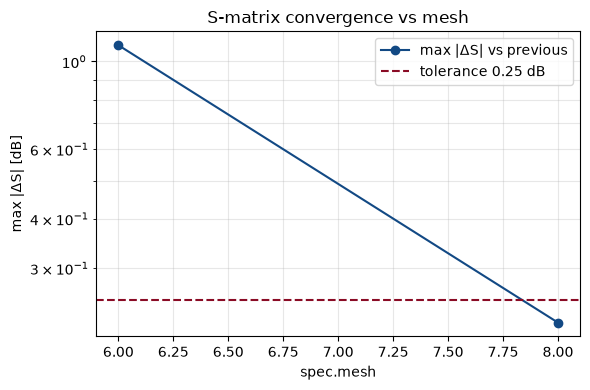

In [3]:
report.plot(tol_db=TOL_DB)
plt.show()

## 2 · The recommended mesh

`recommend` returns the coarsest mesh whose S-matrix had already stopped
moving (< `tol_db` from the previous step) — the one to use for production
runs. Finer than that just burns compute for no accuracy. The tolerance is
*your* engineering call: a foundry spec of ±0.25 dB converges here, while a
strict 0.05 dB would demand a finer sweep.

In [4]:
rec = report.recommend(tol_db=TOL_DB)
print(f"recommended mesh (tol {TOL_DB} dB): {rec}" if rec is not None
      else "not converged — extend the sweep to finer meshes")

recommended mesh (tol 0.25 dB): 8


## 3 · The cache makes repeats free

Every point above was stored under a content hash. Re-running the **identical
sweep** recomputes nothing — each job is a cache hit, so it returns almost
instantly. Change the geometry, technology, spec, or engine version and the
hash changes, so only the genuinely new work reruns.

In [5]:
t0 = time.perf_counter()
again = sweep(get_solver("beamz"), component, tech, spec,
              field="mesh", values=mesh_values, cache_dir=cache, floor_db=-10.0)
warm = time.perf_counter() - t0

print(f"cold sweep (new points): {cold:6.1f} s")
print(f"warm sweep (all cached): {warm:6.3f} s   →  {cold / max(warm, 1e-6):.0f}× faster")
print(f"identical result: {again.recommend(TOL_DB) == rec}")

cold sweep (new points):  127.1 s
warm sweep (all cached):  0.005 s   →  28157× faster
identical result: True


## Recap & next

`sweep` tells you the coarsest mesh that's converged; `run_cached` (and the
`cache_dir=` on `sweep`) means you pay for each distinct job exactly once.
Next: **`07_choosing_an_engine`** — the same job on beamz, tidy3d, and
Lumerical, and how their results line up.